# Лабораторная работа №3

## Анимация движения секущей прямой к заданной линии на плоскости
Кравченко Сергей   
**Курс:** 1  
**Группа:** 5  

---



1. `def` и `lambda` для создания функций;
2. `global` для изменения области видимости переменной;
3. строки документации для функций;
4. функция как аргумент другой функции;
5. `matplotlib.pyplot`: `figure`, `axes`, `axis`, `plot`;
6. графические объекты `Line2D`: методы `get_xdata`, `get_ydata`, `set_data`;
7. `FuncAnimation` из `matplotlib.animation`;
8. `numpy`: `ndarray`, `array`, `arange`, `transpose`, `min`, `max`;
9. `sympy` для вычисления производной при построении касательной.

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import sympy as sp

# Задание 3.1. Анимированное построение линии на плоскости

## Задание 3.1a

Создать анимацию построения графика явно заданной аналитической функции  
$y = y(x)$ по значениям $x$, последовательно изменяющимся от  
$x_{min}$ до $x_{max}$ с шагом `step`.


$$
y(x)=\sin^5(x), \quad x_{min}=1,\quad x_{max}=5,\quad step=0.05.
$$

In [105]:
def y(x):
    return np.sin(x)**5

In [106]:
x_min = 1.
x_max = 5.
step = 0.05

In [107]:
x_array = np.arange(x_min, x_max, step)
y_array = y(x_array)

In [108]:
matrix = np.transpose([x_array, y_array])
matrix[:5]

array([[1.        , 0.4218866 ],
       [1.05      , 0.49108337],
       [1.1       , 0.56220386],
       [1.15      , 0.63356674],
       [1.2       , 0.7033486 ]])

In [109]:
fig1 = plt.figure()

<Figure size 640x480 with 0 Axes>

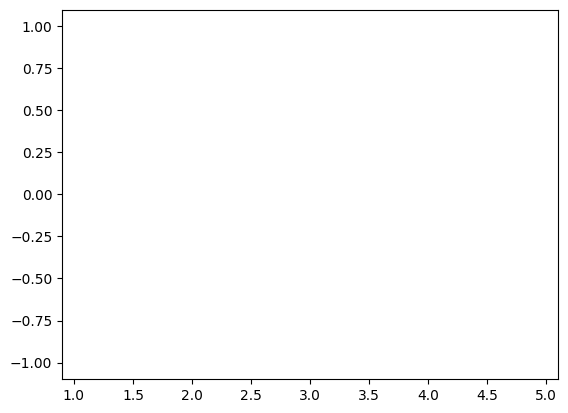

In [110]:
y_min, y_max = np.min(y_array), np.max(y_array)

ax1 = plt.axes()
plt.axis([x_min - 0.1, x_max + 0.1, y_min - 0.1, y_max + 0.1]);

In [111]:
line1, = ax1.plot([], [], 'b')
print(type(line1))
line1.get_xdata(), line1.get_ydata()

<class 'matplotlib.lines.Line2D'>


(array([], dtype=float64), array([], dtype=float64))

In [112]:
def at_frame1(point):

    x_coord = list(line1.get_xdata())
    y_coord = list(line1.get_ydata())

    x_coord.append(point[0])
    y_coord.append(point[1])

    line1.set_data(x_coord, y_coord)

In [113]:
help(at_frame1)

Help on function at_frame1 in module __main__:

at_frame1(point)



In [114]:
print(at_frame1.__doc__)

None


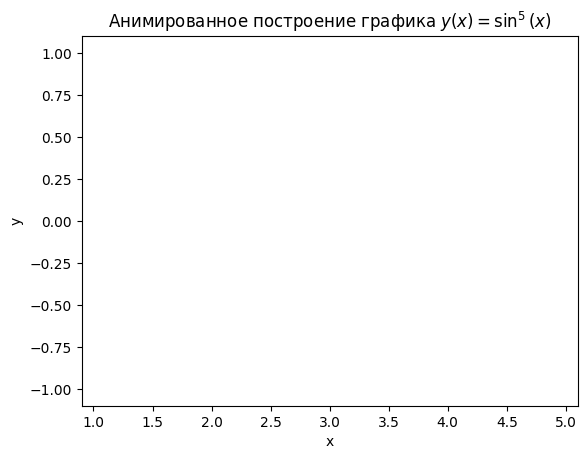

In [115]:
fig1 = plt.figure()
ax1 = plt.axes()
plt.axis([x_min - 0.1, x_max + 0.1, y_min - 0.1, y_max + 0.1])

line1, = ax1.plot([], [], 'b')
plt.title(r'Анимированное построение графика $y(x)=\sin^5(x)$')
plt.xlabel('x')
plt.ylabel('y')

animation_31a = FuncAnimation(fig1, at_frame1, frames=matrix,
                              repeat=False, interval=15)

animation_31a

In [116]:
plt.close('all')

## Задание 3.1b

Создать аналогичную анимацию построения графика параметрически заданной функции

$$
x=x(t), \quad y=y(t)
$$

по значениям $t$, последовательно изменяющимся от $t_{min}$ до $t_{max}$
с шагом

$$
step=
rac{t_{max}-t_{min}}{100}.
$$


используем параметризацию той же линии из примера:

$$
x(t)=t,\qquad y(t)=\sin^5(t),\qquad t\in[1,5].
$$

Эта параметрическая функция непрерывна на выбранном промежутке.

In [117]:
plt.close('all')

x = lambda t: t
y_param = lambda t: np.sin(t)**5

t_min = 1.
t_max = 5.
step_t = (t_max - t_min) / 100

t_array = np.arange(t_min, t_max + step_t, step_t)
x_array = x(t_array)
y_array = y_param(t_array)

matrix = np.transpose([x_array, y_array])

x_min, x_max = np.min(x_array), np.max(x_array)
y_min, y_max = np.min(y_array), np.max(y_array)

In [118]:
def at_frame1b(point):

    x_coord = list(line1b.get_xdata())
    y_coord = list(line1b.get_ydata())

    x_coord.append(point[0])
    y_coord.append(point[1])

    line1b.set_data(x_coord, y_coord)

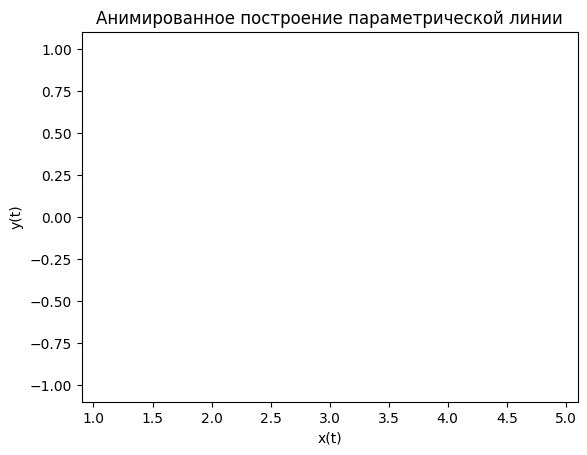

In [119]:
fig1b = plt.figure()
ax1b = plt.axes()
plt.axis([x_min - 0.1, x_max + 0.1, y_min - 0.1, y_max + 0.1])

line1b, = ax1b.plot([], [], 'b')
plt.title(r'Анимированное построение параметрической линии')
plt.xlabel('x(t)')
plt.ylabel('y(t)')

animation_31b = FuncAnimation(fig1b, at_frame1b, frames=matrix,
                              repeat=False, interval=20)

animation_31b

In [120]:
plt.close('all')

# Задание 3.2. Движение точки по линии на плоскости

Создать анимацию движения точки по графику параметрической функции

$$
x=x(t), \quad y=y(t)
$$

по значениям $t$, последовательно изменяющимся от $t_{min}$ до $t_{max}$
с шагом `step`.



Text(0, 0.5, 'y(t)')

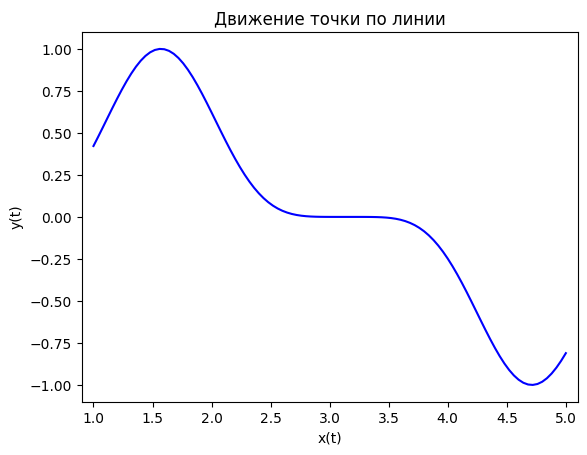

In [121]:
fig2 = plt.figure()
ax2 = plt.axes()
plt.axis([x_min - 0.1, x_max + 0.1, y_min - 0.1, y_max + 0.1])

line1, = ax2.plot(x_array, y_array, 'b')   # объект для графика функции
line2, = ax2.plot([], [], 'go')            # объект для движущейся точки

plt.title('Движение точки по линии')
plt.xlabel('x(t)')
plt.ylabel('y(t)')

In [122]:
def at_frame2(point):
    line2.set_data([point[0]], [point[1]])

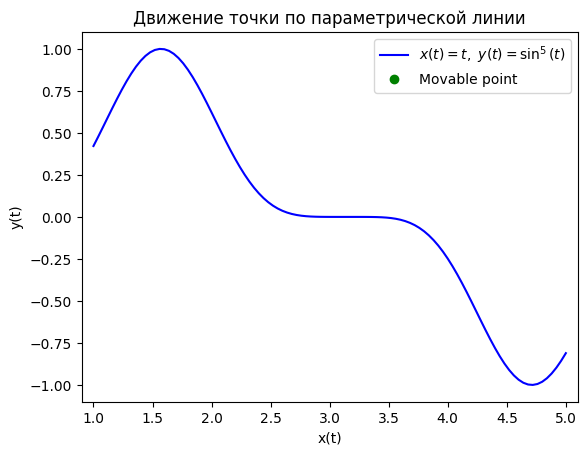

In [123]:
fig2 = plt.figure()
ax2 = plt.axes()
plt.axis([x_min - 0.1, x_max + 0.1, y_min - 0.1, y_max + 0.1])

def init():
    global line2

    line1, = ax2.plot(x_array, y_array, 'b')
    line2, = ax2.plot([], [], 'go')

    plt.title('Движение точки по параметрической линии')
    plt.xlabel('x(t)')
    plt.ylabel('y(t)')
    plt.legend([r'$x(t)=t,\ y(t)=\sin^5(t)$', 'Movable point'])

animation_32 = FuncAnimation(fig2, at_frame2, frames=matrix,
                             init_func=init, repeat=False, interval=20)

animation_32

In [124]:
plt.close('all')

# Задание 3.3. Движение секущей прямой к заданной линии на плоскости

## Версия 1

Линия на плоскости задана графиком параметрической функции

$$
x=x(t),\quad y=y(t),\quad t\in[t_{min},t_{max}]
$$

из задания 3.1b.

Начальная точка

$$
A=(x(t_{min}),y(t_{min}))
$$

является неподвижной точкой.

Точка

$$
B=(x(t_{max}),y(t_{max}))
$$

движется последовательно по линии от конечной точки кривой к неподвижной точке $A$.

Нужно создать анимацию движения секущей прямой, проходящей через точки $A$ и $B$,
до момента совпадения координат точек $A$ и $B$, когда секущая становится
касательной прямой к заданной линии в начальной точке $A$.


In [125]:
# Символьное вычисление производной dy/dx для параметрической функции
t = sp.Symbol('t')

x_sym = t
y_sym = sp.sin(t)**5

dx_dt = sp.diff(x_sym, t)
dy_dt = sp.diff(y_sym, t)

dy_dx = sp.simplify(dy_dt / dx_dt)

slope_A = float(dy_dx.subs(t, t_min))
slope_B = float(dy_dx.subs(t, t_max))

dy_dx, slope_A, slope_B

(5*sin(t)**4*cos(t), 1.354451339687763, 1.1992471629269967)

In [126]:
def tangent_points(point, slope):

    x0, y0 = point[0], point[1]

    x_left = x_min - 0.4
    x_right = x_max + 0.4

    y_left = y0 + slope * (x_left - x0)
    y_right = y0 + slope * (x_right - x0)

    return np.array([[x_left, y_left], [x_right, y_right]])

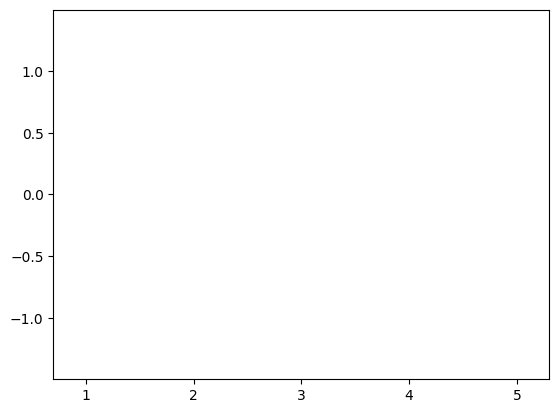

In [127]:
fig3 = plt.figure()
ax3 = plt.axes()
plt.axis([x_min - 0.3, x_max + 0.3, y_min - 0.5, y_max + 0.5])

def init3():

    global point_B, secant_line

    curve, = ax3.plot(x_array, y_array, 'b')

    A = np.array([x_array[0], y_array[0]])
    point_A, = ax3.plot(A[0], A[1], 'ro')

    B = np.array([x_array[-1], y_array[-1]])
    point_B, = ax3.plot(B[0], B[1], 'go')

    secant_p = [A + (B - A) * k for k in [-2, 2]]
    secant_p = np.array(secant_p)
    secant_line, = ax3.plot(secant_p[:, 0], secant_p[:, 1], 'g')

    plt.title('Секущая прямая: версия 1')
    plt.xlabel('x(t)')
    plt.ylabel('y(t)')
    plt.legend([r'$x(t)=t,\ y(t)=\sin^5(t)$',
                'Unmovable point A',
                'Movable point B',
                'Secant line'])

In [128]:
def at_frame3(point):

    A = np.array([x_array[0], y_array[0]])
    B = np.array([point[0], point[1]])

    point_B.set_data([B[0]], [B[1]])

    if np.allclose(A, B):
        tangent_p = tangent_points(A, slope_A)
        secant_line.set_data(tangent_p[:, 0], tangent_p[:, 1])
        secant_line.set_color('r')
    else:
        secant_p = [A + (B - A) * k for k in [-2, 2]]
        secant_p = np.array(secant_p)
        secant_line.set_data(secant_p[:, 0], secant_p[:, 1])
        secant_line.set_color('g')

In [129]:
print(at_frame3.__doc__)

None


In [130]:
animation_33 = FuncAnimation(fig3, at_frame3, frames=matrix[::-1],
                             init_func=init3, repeat=False, interval=20)

animation_33

In [131]:
plt.close('all')

# Задание 3.4. Движение секущей прямой к заданной линии на плоскости

## Версия 2

Линия на плоскости задана графиком параметрической функции

$$
x=x(t),\quad y=y(t),\quad t\in[t_{min},t_{max}]
$$

из задания 3.1b.

Точка

$$
A=(x(t_{min}),y(t_{min}))
$$

является подвижной точкой на заданной линии.

Точка

$$
B=(x(t_{max}),y(t_{max}))
$$

является неподвижной точкой.

Точка $A$ движется последовательно по кривой до неподвижной точки $B$.



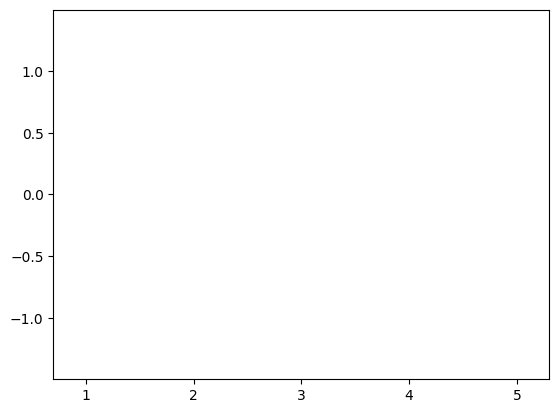

In [132]:
fig4 = plt.figure()
ax4 = plt.axes()
plt.axis([x_min - 0.3, x_max + 0.3, y_min - 0.5, y_max + 0.5])

def init4():
    global point_A, secant_line_4

    curve, = ax4.plot(x_array, y_array, 'b')

    A = np.array([x_array[0], y_array[0]])
    point_A, = ax4.plot(A[0], A[1], 'go')

    B = np.array([x_array[-1], y_array[-1]])
    point_B, = ax4.plot(B[0], B[1], 'ro')

    secant_p = [B + (A - B) * k for k in [-2, 2]]
    secant_p = np.array(secant_p)
    secant_line_4, = ax4.plot(secant_p[:, 0], secant_p[:, 1], 'g')

    plt.title('Секущая прямая: версия 2')
    plt.xlabel('x(t)')
    plt.ylabel('y(t)')
    plt.legend([r'$x(t)=t,\ y(t)=\sin^5(t)$',
                'Movable point A',
                'Unmovable point B',
                'Secant line'])

In [133]:
def at_frame4(point):

    A = np.array([point[0], point[1]])
    B = np.array([x_array[-1], y_array[-1]])

    point_A.set_data([A[0]], [A[1]])

    if np.allclose(A, B):
        tangent_p = tangent_points(B, slope_B)
        secant_line_4.set_data(tangent_p[:, 0], tangent_p[:, 1])
        secant_line_4.set_color('r')
    else:
        secant_p = [B + (A - B) * k for k in [-2, 2]]
        secant_p = np.array(secant_p)
        secant_line_4.set_data(secant_p[:, 0], secant_p[:, 1])
        secant_line_4.set_color('g')

In [134]:
print(at_frame4.__doc__)

None


In [135]:
animation_34 = FuncAnimation(fig4, at_frame4, frames=matrix,
                             init_func=init4, repeat=False, interval=20)

animation_34

In [136]:
plt.close('all')